# 08 — Comparação dos modelos

Este notebook compara TF-IDF + Regressão Logística e BERTimbau no mesmo conjunto de validação. A comparação inclui as métricas exigidas pela Sprint 3, matrizes de confusão, análise pareada dos erros, teste de McNemar e intervalos por bootstrap agrupado por reunião.

> **Limite metodológico:** a referência ainda são pseudo-rótulos. O resultado serve para comparar os algoritmos dentro deste experimento, mas a decisão final depende do conjunto humano reservado.

**Objetivo e conexão com o projeto.** Os dois classificadores são comparados caso a caso no mesmo conjunto de validação, com métricas de classe, análise de discordâncias e incerteza agrupada por reunião. A decisão resultante é provisória: ela combina qualidade preditiva, custo dos erros e custo computacional, mas permanece condicionada ao futuro conjunto de teste humano.


## 1. Critério de decisão

O **recall da classe oportunidade** é a métrica principal: um falso negativo pode esconder uma oportunidade comercial que não chegará ao time responsável. Precision continua importante para controlar o volume de revisões, enquanto F1 resume esse equilíbrio. Accuracy não deve ser usada isoladamente porque pode mascarar desempenho desigual entre classes.

A análise é pareada por `chunk_id`, e o bootstrap reamostra reuniões inteiras. Assim, respeitamos a dependência existente entre chunks da mesma reunião.

As escolhas abaixo delimitam o experimento e devem ser lidas antes da implementação. Elas registram o que o código efetivamente faz e quais limitações precisam permanecer visíveis na interpretação.


## 2. Preparação do ambiente

Nesta célula são reunidos imports, parâmetros e caminhos necessários à etapa. Centralizar essa preparação antes do processamento deixa as dependências explícitas e evita que configurações importantes fiquem dispersas entre transformações, treinamento ou avaliação.


In [ ]:
from __future__ import annotations

import json
import os
import tempfile
from collections import defaultdict
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "wedjat-matplotlib"))

import matplotlib.pyplot as plt
import numpy as np
import scipy
import sklearn
from scipy.stats import binomtest
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    average_precision_score,
    brier_score_loss,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)

SEED = 42
BOOTSTRAP_REPETITIONS = 2_000


### Função auxiliar: `find_project_root`

Esta célula isola a responsabilidade implementada por `find_project_root`. A definição prepara essa operação para uso nas células seguintes e não altera os dados até ser chamada.


In [ ]:
def find_project_root() -> Path:
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (candidate / "data").exists() and (candidate / "notebooks").exists():
            return candidate
    raise FileNotFoundError("Raiz do projeto não encontrada. No Colab, entre na pasta Wedjat.")


### Preparação dos objetos desta etapa

A célula prepara `ROOT`, `BASELINE_METRICS_PATH`, `BERT_METRICS_PATH`, `BASELINE_PREDICTIONS_PATH` para a operação seguinte. O agrupamento mantém juntas apenas atribuições relacionadas e deixa a execução principal em uma célula própria.


In [1]:
ROOT = find_project_root()
BASELINE_METRICS_PATH = ROOT / "reports/metrics/baseline_tfidf_logreg_metrics.json"
BERT_METRICS_PATH = ROOT / "reports/metrics/bertimbau_finetuning_metrics.json"
BASELINE_PREDICTIONS_PATH = ROOT / "data/processed/baseline_tfidf_logreg_validation_predictions.jsonl"
BERT_PREDICTIONS_PATH = ROOT / "data/processed/bertimbau_validation_predictions.jsonl"
BASELINE_MODEL_PATH = ROOT / "data/processed/baseline_tfidf_logreg.joblib"
BERT_MODEL_PATH = ROOT / "data/processed/bertimbau_opportunity_best/model.safetensors"
REPORT_PATH = ROOT / "reports/metrics/model_comparison.json"
METRICS_FIGURE_PATH = ROOT / "reports/figures/model_comparison_metrics.png"
MATRICES_FIGURE_PATH = ROOT / "reports/figures/model_comparison_confusion_matrices.png"
DISAGREEMENTS_PATH = ROOT / "data/processed/model_comparison_disagreements.jsonl"

print({"numpy": np.__version__, "scikit_learn": sklearn.__version__, "scipy": scipy.__version__})


{'numpy': '2.5.3', 'scikit_learn': '1.9.1', 'scipy': '1.18.1'}


## 3. Validação da comparabilidade

Não basta ler dois relatórios: conferimos que cada linha possui o mesmo chunk, reunião e pseudo-rótulo, na mesma ordem. Se essa condição falhar, o notebook interrompe a execução.

As verificações desta seção funcionam como critérios de integridade. Elas não melhoram as métricas por si mesmas, mas impedem que a análise prossiga silenciosamente com IDs repetidos, campos ausentes ou relações inconsistentes.


In [ ]:
def read_jsonl(path: Path) -> list[dict]:
    with path.open(encoding="utf-8") as file:
        return [json.loads(line) for line in file if line.strip()]


### Verificações de integridade

As asserções tornam explícitas as condições que precisam permanecer verdadeiras para que os resultados sejam considerados consistentes.


In [2]:
baseline_report = json.loads(BASELINE_METRICS_PATH.read_text(encoding="utf-8"))
bert_report = json.loads(BERT_METRICS_PATH.read_text(encoding="utf-8"))
baseline_rows = read_jsonl(BASELINE_PREDICTIONS_PATH)
bert_rows = read_jsonl(BERT_PREDICTIONS_PATH)

assert len(baseline_rows) == len(bert_rows) > 0
assert baseline_report["evaluation_reference"] == bert_report["evaluation_reference"]
assert baseline_report["validation_chunks"] == bert_report["validation_chunks"] == len(baseline_rows)
assert baseline_report["validation_meetings"] == bert_report["validation_meetings"]
for baseline_row, bert_row in zip(baseline_rows, bert_rows):
    assert baseline_row["chunk_id"] == bert_row["chunk_id"]
    assert baseline_row["meeting_id"] == bert_row["meeting_id"]
    assert baseline_row["pseudo_label"] == bert_row["pseudo_label"]
    assert "text" not in baseline_row and "text" not in bert_row

meeting_ids = np.asarray([row["meeting_id"] for row in baseline_rows])
chunk_ids = [row["chunk_id"] for row in baseline_rows]
y_true = np.asarray([row["pseudo_label"] for row in baseline_rows], dtype=np.int64)
baseline_predictions = np.asarray([row["prediction"] for row in baseline_rows], dtype=np.int64)
bert_predictions = np.asarray([row["prediction"] for row in bert_rows], dtype=np.int64)
baseline_probabilities = np.asarray([row["probability_oportunidade"] for row in baseline_rows], dtype=np.float64)
bert_probabilities = np.asarray([row["probability_oportunidade"] for row in bert_rows], dtype=np.float64)
unique_meetings = np.unique(meeting_ids)

print({
    "paired_chunks": len(y_true),
    "validation_meetings": len(unique_meetings),
    "same_reference": True,
    "texts_in_prediction_files": False,
})


{'paired_chunks': 140, 'validation_meetings': 98, 'same_reference': True, 'texts_in_prediction_files': False}


## 4. Métricas lado a lado

As métricas são recalculadas a partir das previsões pareadas, em vez de apenas copiar valores dos relatórios anteriores.

As métricas são calculadas sobre a mesma referência usada pelo experimento. Precision, recall e F1 complementam a acurácia e ajudam a distinguir o custo de falsos positivos e falsos negativos.


In [ ]:
def calculate_metrics(labels: np.ndarray, predictions: np.ndarray) -> dict[str, float]:
    return {
        "accuracy": float(accuracy_score(labels, predictions)),
        "precision_oportunidade": float(precision_score(labels, predictions, zero_division=0)),
        "recall_oportunidade": float(recall_score(labels, predictions, zero_division=0)),
        "f1_oportunidade": float(f1_score(labels, predictions, zero_division=0)),
        "f1_macro": float(f1_score(labels, predictions, average="macro", zero_division=0)),
    }


### Preparação dos objetos desta etapa

A célula prepara `baseline_metrics`, `bert_metrics`, `metric_comparison` para a operação seguinte. O agrupamento mantém juntas apenas atribuições relacionadas e deixa a execução principal em uma célula própria.


In [3]:
baseline_metrics = calculate_metrics(y_true, baseline_predictions)
bert_metrics = calculate_metrics(y_true, bert_predictions)
metric_comparison = {}
for metric_name in baseline_metrics:
    baseline_value = baseline_metrics[metric_name]
    bert_value = bert_metrics[metric_name]
    if np.isclose(baseline_value, bert_value):
        winner = "empate"
    else:
        winner = "bertimbau" if bert_value > baseline_value else "baseline_tfidf_logreg"
    metric_comparison[metric_name] = {
        "baseline_tfidf_logreg": baseline_value,
        "bertimbau": bert_value,
        "delta_bertimbau_minus_baseline": bert_value - baseline_value,
        "winner": winner,
    }

for metric_name, values in metric_comparison.items():
    print({
        "metric": metric_name,
        "baseline": round(values["baseline_tfidf_logreg"], 4),
        "bertimbau": round(values["bertimbau"], 4),
        "delta": round(values["delta_bertimbau_minus_baseline"], 4),
        "winner": values["winner"],
    })


{'metric': 'accuracy', 'baseline': 0.9571, 'bertimbau': 0.9786, 'delta': 0.0214, 'winner': 'bertimbau'}
{'metric': 'precision_oportunidade', 'baseline': 0.9062, 'bertimbau': 0.9661, 'delta': 0.0599, 'winner': 'bertimbau'}
{'metric': 'recall_oportunidade', 'baseline': 1.0, 'bertimbau': 0.9828, 'delta': -0.0172, 'winner': 'baseline_tfidf_logreg'}
{'metric': 'f1_oportunidade', 'baseline': 0.9508, 'bertimbau': 0.9744, 'delta': 0.0235, 'winner': 'bertimbau'}
{'metric': 'f1_macro', 'baseline': 0.9564, 'bertimbau': 0.978, 'delta': 0.0216, 'winner': 'bertimbau'}


## 5. Análise pareada dos erros

O teste exato de McNemar usa apenas os casos em que os modelos discordam quanto ao acerto. Com poucos casos discordantes, o valor-p tende a ser pouco conclusivo; ele será registrado, não usado como prova isolada.


In [4]:
baseline_correct = baseline_predictions == y_true
bert_correct = bert_predictions == y_true
paired_outcomes = {
    "both_correct": int(np.sum(baseline_correct & bert_correct)),
    "baseline_only_correct": int(np.sum(baseline_correct & ~bert_correct)),
    "bertimbau_only_correct": int(np.sum(~baseline_correct & bert_correct)),
    "both_wrong": int(np.sum(~baseline_correct & ~bert_correct)),
}
discordant_total = paired_outcomes["baseline_only_correct"] + paired_outcomes["bertimbau_only_correct"]
mcnemar_pvalue = (
    float(binomtest(paired_outcomes["bertimbau_only_correct"], discordant_total, p=0.5).pvalue)
    if discordant_total else 1.0
)

disagreement_rows = []
for index in np.flatnonzero(baseline_predictions != bert_predictions):
    disagreement_rows.append({
        "meeting_id": str(meeting_ids[index]),
        "chunk_id": chunk_ids[index],
        "pseudo_label": int(y_true[index]),
        "baseline_prediction": int(baseline_predictions[index]),
        "bertimbau_prediction": int(bert_predictions[index]),
        "baseline_correct": bool(baseline_correct[index]),
        "bertimbau_correct": bool(bert_correct[index]),
    })
with DISAGREEMENTS_PATH.open("w", encoding="utf-8") as file:
    for row in disagreement_rows:
        file.write(json.dumps(row, ensure_ascii=False) + "\n")

print({**paired_outcomes, "discordant_total": discordant_total, "mcnemar_exact_pvalue": round(mcnemar_pvalue, 4)})

{'both_correct': 133, 'baseline_only_correct': 1, 'bertimbau_only_correct': 4, 'both_wrong': 2, 'discordant_total': 5, 'mcnemar_exact_pvalue': 0.375}


## 6. Bootstrap agrupado por reunião

Reamostramos as 98 reuniões com reposição e recalculamos a diferença `BERTimbau − baseline` duas mil vezes. O intervalo de 95% descreve a incerteza neste conjunto; não corrige o viés dos pseudo-rótulos.

O reamostramento é agrupado por reunião para preservar a dependência entre chunks do mesmo encontro. O intervalo resultante mostra a variabilidade da diferença entre modelos, em vez de apresentar apenas uma estimativa pontual.


In [ ]:
indices_by_meeting: dict[str, list[int]] = defaultdict(list)
for index, meeting_id in enumerate(meeting_ids):
    indices_by_meeting[str(meeting_id)].append(index)
meeting_list = sorted(indices_by_meeting)
rng = np.random.default_rng(SEED)
bootstrap_deltas = {metric_name: [] for metric_name in baseline_metrics}

for _ in range(BOOTSTRAP_REPETITIONS):
    sampled_meetings = rng.choice(meeting_list, size=len(meeting_list), replace=True)
    sampled_indices = np.asarray(
        [index for meeting_id in sampled_meetings for index in indices_by_meeting[str(meeting_id)]],
        dtype=np.int64,
    )
    sampled_labels = y_true[sampled_indices]
    sampled_baseline = calculate_metrics(sampled_labels, baseline_predictions[sampled_indices])
    sampled_bert = calculate_metrics(sampled_labels, bert_predictions[sampled_indices])
    for metric_name in bootstrap_deltas:
        bootstrap_deltas[metric_name].append(sampled_bert[metric_name] - sampled_baseline[metric_name])

bootstrap_summary = {}
for metric_name, deltas in bootstrap_deltas.items():
    values = np.asarray(deltas)
    bootstrap_summary[metric_name] = {
        "observed_delta": metric_comparison[metric_name]["delta_bertimbau_minus_baseline"],
        "ci95_low": float(np.quantile(values, 0.025)),
        "ci95_high": float(np.quantile(values, 0.975)),
        "probability_bertimbau_better": float(np.mean(values > 0)),
    }


### Execução da etapa

A célula aplica os objetos e funções preparados anteriormente a uma responsabilidade específica do fluxo. As saídas permanecem disponíveis para validação e interpretação nas células seguintes.


In [5]:
for metric_name, values in bootstrap_summary.items():
    print({
        "metric": metric_name,
        "delta": round(values["observed_delta"], 4),
        "ci95": [round(values["ci95_low"], 4), round(values["ci95_high"], 4)],
        "p_bertimbau_better": round(values["probability_bertimbau_better"], 4),
    })


{'metric': 'accuracy', 'delta': 0.0214, 'ci95': [-0.0078, 0.0585], 'p_bertimbau_better': 0.8275}
{'metric': 'precision_oportunidade', 'delta': 0.0599, 'ci95': [-0.0002, 0.1339], 'p_bertimbau_better': 0.9515}
{'metric': 'recall_oportunidade', 'delta': -0.0172, 'ci95': [-0.0556, 0.0], 'p_bertimbau_better': 0.0}
{'metric': 'f1_oportunidade', 'delta': 0.0235, 'ci95': [-0.0133, 0.0679], 'p_bertimbau_better': 0.8275}
{'metric': 'f1_macro', 'delta': 0.0216, 'ci95': [-0.0094, 0.0593], 'p_bertimbau_better': 0.835}


## 7. Análise para escolha do melhor modelo

Além das classes finais, avaliamos a ordenação e a qualidade das probabilidades. O Brier score mede o erro quadrático das probabilidades e deve ser menor. Também explicitamos o custo relativo dos erros: considerando custo 1 para revisar um falso positivo, o baseline custa 6 e o BERTimbau custa `2 + custo_FN`. O ponto de empate ocorre quando um falso negativo custa quatro vezes uma revisão.

A busca de um limiar com recall total é apenas diagnóstica, pois foi feita na própria validação. O limiar final deverá ser calibrado nos dados humanos.


In [ ]:
probability_quality = {
    "baseline_tfidf_logreg": {
        "roc_auc": float(roc_auc_score(y_true, baseline_probabilities)),
        "average_precision": float(average_precision_score(y_true, baseline_probabilities)),
        "brier_score": float(brier_score_loss(y_true, baseline_probabilities)),
    },
    "bertimbau": {
        "roc_auc": float(roc_auc_score(y_true, bert_probabilities)),
        "average_precision": float(average_precision_score(y_true, bert_probabilities)),
        "brier_score": float(brier_score_loss(y_true, bert_probabilities)),
    },
}


### Função auxiliar: `diagnostic_threshold_for_full_recall`

Esta célula isola a responsabilidade implementada por `diagnostic_threshold_for_full_recall`. A definição prepara essa operação para uso nas células seguintes e não altera os dados até ser chamada.


In [ ]:
def diagnostic_threshold_for_full_recall(probabilities: np.ndarray) -> dict:
    threshold = float(np.min(probabilities[y_true == 1]))
    predictions = (probabilities >= threshold).astype(np.int64)
    matrix = confusion_matrix(y_true, predictions, labels=[0, 1])
    tn_value, fp_value, fn_value, tp_value = (int(value) for value in matrix.ravel())
    return {
        "threshold": threshold,
        "precision_oportunidade": float(precision_score(y_true, predictions, zero_division=0)),
        "recall_oportunidade": float(recall_score(y_true, predictions, zero_division=0)),
        "f1_oportunidade": float(f1_score(y_true, predictions, zero_division=0)),
        "false_positive": fp_value,
        "false_negative": fn_value,
        "warning": "Diagnóstico na validação; não usar como limiar final.",
    }


### Preparação dos objetos desta etapa

A célula prepara `full_recall_diagnostic`, `baseline_fp`, `baseline_fn`, `bert_fp` para a operação seguinte. O agrupamento mantém juntas apenas atribuições relacionadas e deixa a execução principal em uma célula própria.


In [ ]:
full_recall_diagnostic = {
    "baseline_tfidf_logreg": diagnostic_threshold_for_full_recall(baseline_probabilities),
    "bertimbau": diagnostic_threshold_for_full_recall(bert_probabilities),
}
baseline_fp = int(np.sum((baseline_predictions == 1) & (y_true == 0)))
baseline_fn = int(np.sum((baseline_predictions == 0) & (y_true == 1)))
bert_fp = int(np.sum((bert_predictions == 1) & (y_true == 0)))
bert_fn = int(np.sum((bert_predictions == 0) & (y_true == 1)))
false_negative_cost_break_even = (baseline_fp - bert_fp) / (bert_fn - baseline_fn)
resource_tradeoff = {
    "baseline_fit_seconds": float(baseline_report["fit_seconds"]),
    "bertimbau_training_seconds": float(bert_report["training_seconds"]),
    "baseline_model_size_mb": BASELINE_MODEL_PATH.stat().st_size / 1024**2,
    "bertimbau_model_size_mb": BERT_MODEL_PATH.stat().st_size / 1024**2,
}
best_model_current_experiment = "bertimbau"
selection_reasons = [
    "Venceu em accuracy, precision, F1 de oportunidade e F1 macro.",
    "Cometeu três erros contra seis do baseline no mesmo conjunto.",
    "Acertou sozinho quatro casos, enquanto o baseline acertou sozinho um.",
    "Apresentou Brier score menor, indicando probabilidades mais próximas dos pseudo-rótulos.",
    "O recall pode ser priorizado depois por calibração de limiar em dados humanos.",
]


### Execução da etapa

A célula aplica os objetos e funções preparados anteriormente a uma responsabilidade específica do fluxo. As saídas permanecem disponíveis para validação e interpretação nas células seguintes.


In [6]:
print({
    "best_model_current_experiment": best_model_current_experiment,
    "brier_baseline": round(probability_quality["baseline_tfidf_logreg"]["brier_score"], 4),
    "brier_bertimbau": round(probability_quality["bertimbau"]["brier_score"], 4),
    "false_negative_cost_break_even": false_negative_cost_break_even,
    "baseline_model_mb": round(resource_tradeoff["baseline_model_size_mb"], 2),
    "bertimbau_model_mb": round(resource_tradeoff["bertimbau_model_size_mb"], 2),
})


{'best_model_current_experiment': 'bertimbau', 'brier_baseline': 0.1061, 'brier_bertimbau': 0.0159, 'false_negative_cost_break_even': 4.0, 'baseline_model_mb': 0.69, 'bertimbau_model_mb': 415.54}


## 8. Visualizações comparativas

As barras usam escala completa de 0 a 1 para não exagerar pequenas diferenças. As matrizes usam a mesma ordem de classes.

A comparação mantém dados e referência constantes para que a diferença observada seja atribuída aos métodos. Resultados próximos devem ser interpretados com a incerteza estatística e o custo operacional em mente.


In [ ]:
METRICS_FIGURE_PATH.parent.mkdir(parents=True, exist_ok=True)
metric_keys = ["accuracy", "precision_oportunidade", "recall_oportunidade", "f1_oportunidade", "f1_macro"]
metric_labels = ["Accuracy", "Precision\noportunidade", "Recall\noportunidade", "F1\noportunidade", "F1 macro"]
positions = np.arange(len(metric_keys))
width = 0.36
fig, ax = plt.subplots(figsize=(10, 5.5))
baseline_bars = ax.bar(positions - width / 2, [baseline_metrics[key] for key in metric_keys], width, label="TF-IDF + LogReg", color="#4C78A8")
bert_bars = ax.bar(positions + width / 2, [bert_metrics[key] for key in metric_keys], width, label="BERTimbau", color="#7A5195")
ax.bar_label(baseline_bars, fmt="%.3f", padding=3, fontsize=9)
ax.bar_label(bert_bars, fmt="%.3f", padding=3, fontsize=9)
ax.set_xticks(positions, metric_labels)
ax.set_ylim(0, 1.08)
ax.set_ylabel("Pontuação")
ax.set_title("Comparação na validação com pseudo-rótulos")
ax.legend(loc="lower right")
ax.grid(axis="y", alpha=0.2)
fig.tight_layout()
fig.savefig(METRICS_FIGURE_PATH, dpi=160, bbox_inches="tight")
plt.show()

baseline_matrix = confusion_matrix(y_true, baseline_predictions, labels=[0, 1])
bert_matrix = confusion_matrix(y_true, bert_predictions, labels=[0, 1])
fig, axes = plt.subplots(1, 2, figsize=(11, 4.8))


### Visualização da matriz de confusão

A matriz apresenta acertos e erros por classe. Ela complementa as métricas agregadas ao mostrar diretamente quais tipos de erro ocorreram.


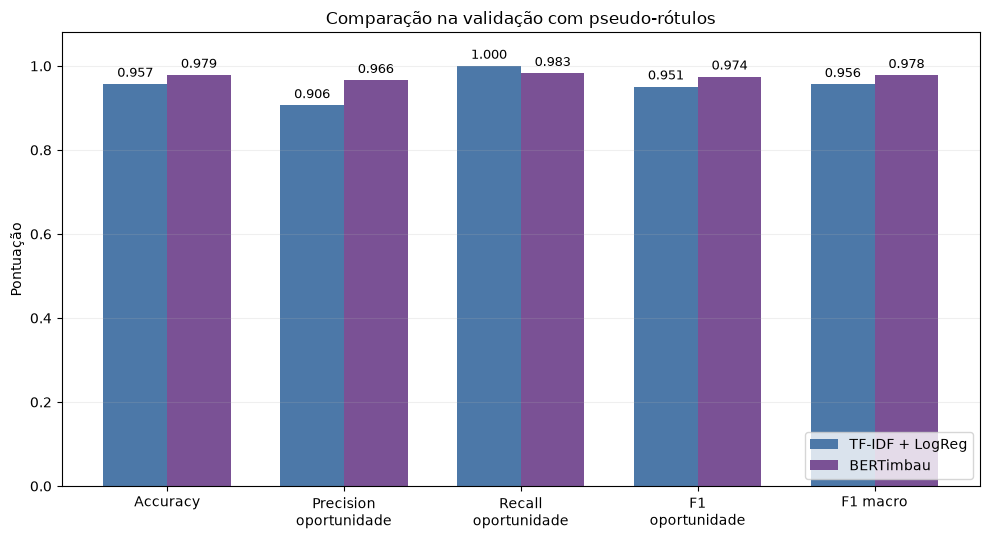

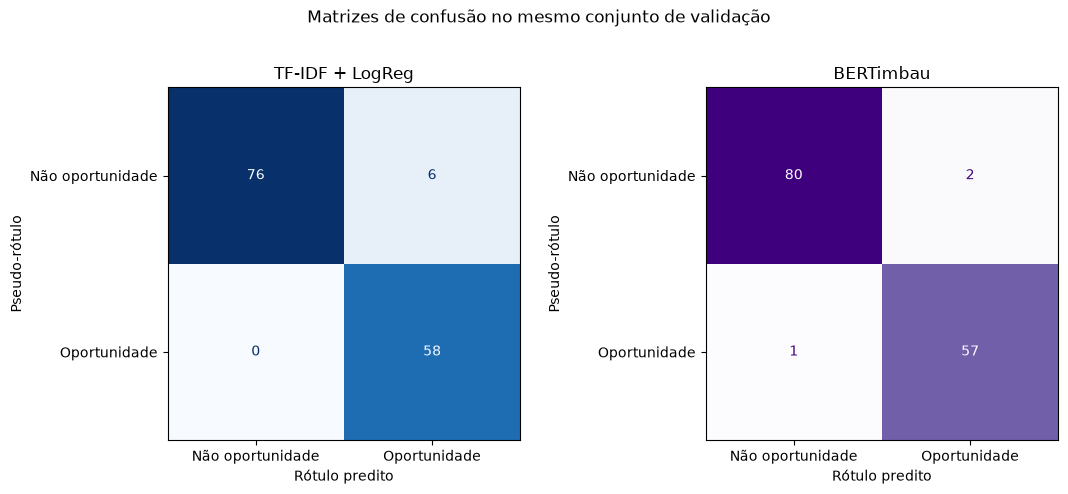

In [7]:
for axis, matrix, title, color in [
    (axes[0], baseline_matrix, "TF-IDF + LogReg", "Blues"),
    (axes[1], bert_matrix, "BERTimbau", "Purples"),
]:
    display = ConfusionMatrixDisplay(matrix, display_labels=["Não oportunidade", "Oportunidade"])
    display.plot(ax=axis, cmap=color, values_format="d", colorbar=False)
    axis.set_title(title)
    axis.set_xlabel("Rótulo predito")
    axis.set_ylabel("Pseudo-rótulo")
fig.suptitle("Matrizes de confusão no mesmo conjunto de validação", y=1.02)
fig.tight_layout()
fig.savefig(MATRICES_FIGURE_PATH, dpi=160, bbox_inches="tight")
plt.show()


## 9. Melhor modelo do experimento e relatório

**Escolha provisória: BERTimbau.** Ele vence quatro das cinco métricas principais, reduz os erros de seis para três e produz probabilidades com Brier score muito menor. O baseline continua sendo a referência mais barata e obteve recall 100% no limiar padrão. Se o negócio definir que um falso negativo custa pelo menos quatro vezes uma revisão, o baseline passa a ter menor custo neste conjunto. A escolha do BERTimbau é a melhor para o experimento atual, mas ainda precisa ser confirmada na auditoria humana.


In [ ]:
report = {
    "schema_version": "1.0",
    "evaluation_reference": baseline_report["evaluation_reference"],
    "warning": "Comparação contra pseudo-rótulos; a decisão final exige o conjunto humano reservado.",
    "paired_chunks": len(y_true),
    "validation_meetings": len(unique_meetings),
    "same_split_verified": True,
    "metrics": metric_comparison,
    "confusion_matrices": {
        "order": [["TN", "FP"], ["FN", "TP"]],
        "baseline_tfidf_logreg": baseline_matrix.tolist(),
        "bertimbau": bert_matrix.tolist(),
    },
    "paired_outcomes": paired_outcomes,
    "probability_quality": probability_quality,
    "full_recall_threshold_diagnostic": full_recall_diagnostic,
    "operational_cost_analysis": {
        "false_positive_cost": 1.0,
        "false_negative_cost_break_even": false_negative_cost_break_even,
        "interpretation": "BERTimbau tem menor custo se FN custar menos de 4 revisões; baseline tem menor custo se custar mais de 4.",
    },
    "resource_tradeoff": resource_tradeoff,
    "mcnemar_exact": {
        "discordant_total": discordant_total,
        "pvalue_two_sided": mcnemar_pvalue,
        "interpretation": "A diferença de acertos não é conclusiva com esta amostra se p >= 0.05.",
    },
    "grouped_bootstrap": {
        "unit": "meeting_id",
        "repetitions": BOOTSTRAP_REPETITIONS,
        "seed": SEED,
        "delta_order": "bertimbau_minus_baseline",
        "metrics": bootstrap_summary,
    },
    "decision": {
        "primary_metric": "recall_oportunidade",
        "primary_metric_justification": "Falsos negativos podem impedir que oportunidades comerciais cheguem ao time responsável.",
        "primary_metric_winner_on_pseudo_labels": "baseline_tfidf_logreg",
        "balanced_performance_winner_on_pseudo_labels": "bertimbau",
        "best_model_current_experiment": best_model_current_experiment,
        "selection_status": "provisional_until_human_evaluation",
        "selection_reasons": selection_reasons,
        "final_model_selected": None,
        "next_gate": "Rotular a auditoria humana e repetir a comparação em reuniões nunca usadas no desenvolvimento.",
    },
}


### Persistência dos artefatos

Os resultados desta etapa são gravados nos caminhos definidos para consumo posterior. O conteúdo persistido segue o contrato já estabelecido pelo projeto.


In [8]:
REPORT_PATH.parent.mkdir(parents=True, exist_ok=True)
REPORT_PATH.write_text(json.dumps(report, ensure_ascii=False, indent=2) + "\n", encoding="utf-8")

print({
    "primary_metric": report["decision"]["primary_metric"],
    "primary_metric_winner": report["decision"]["primary_metric_winner_on_pseudo_labels"],
    "balanced_winner": report["decision"]["balanced_performance_winner_on_pseudo_labels"],
    "best_model_current_experiment": report["decision"]["best_model_current_experiment"],
    "final_model_selected": report["decision"]["final_model_selected"],
    "next_gate": report["decision"]["next_gate"],
})


{'primary_metric': 'recall_oportunidade', 'primary_metric_winner': 'baseline_tfidf_logreg', 'balanced_winner': 'bertimbau', 'best_model_current_experiment': 'bertimbau', 'final_model_selected': None, 'next_gate': 'Rotular a auditoria humana e repetir a comparação em reuniões nunca usadas no desenvolvimento.'}
